# Problem framing

## Clearly and Consisely 

### Main goal : 
Predict if an applicant is approved for a loan

### Context: 
In Banking sector, loans are major risks.\
Banks need to balance **profit** from lending with **minimizing losses** from defaults.

### Values:

##### Benefits analysis

* Human Error Reduction
* Tasks Automation
* Quick decision during loan approval
* Diminution financial loss

##### Cost analysis

* **Investissements** (machine, or renting one, ...)
* **Maintenances**
* **Regulatory monitoring** (ensuring the model complies with the law)


More benefits than costs, so can continue


### Can be without ML:
It can be solved without ML\
par des :
  * Rigid rules (fixed codes)
  * Manual analyses performed by banking experts

However, ML is **flexible and performant**, donc avec ML

### Quality of data
Normaly :
* Bank data is **qualitative**, to prevent losses
* It is also **quantitative**, as banks interact with many individuals.
* These data are from kaggle, on of the best website concerning datasets

## Technically

### Goal 
The objective is to build a **binary classification** model that predicts : `loans_status`
### Success and Failure Metrics
- **1** if approved  
- **0** if rejected

### Input and Output of the model:
According to the `test.csv` files these must be part of the inputs,

***but for better performance, we need to modify them***

* `person_age` – can be used as-is
* `person_income` – transformed using `log(1 + X)` to reduce skew
* `person_home_ownership` – one-hot encoded (`RENT`, `OWN`, `OTHER`)
* `person_emp_length` – can be used as-is
* `loan_intent` – one-hot encoded
* `loan_grade` – ordinal encoding (`A=0` … `G=6`)
* `loan_amnt` – transformed using `log(1 + X)` for scaling
* `loan_int_rate` – can be used as-is
* `loan_percent_income` – can be used as-is
* `cb_person_default_on_file` – mapped to 0 (`N`) / 1 (`Y`)
* `cb_person_cred_hist_length` – can be used as-is

The `ouput` should be the **loan approval status (`loan_status`)**

### Performance Measure:
Performance is evaluated by using the **Area Under the ROC Curve (AUC)** on kaggle
### Non ML Baseline:
Before applying some complex ML models, we should know that:
* Simple threshold rule ( Income > X )
* Logistic Regression
* Traditional credit scoring systems

# Data Collection

All datas are from kaggle playgroundSeries.\
The dataset have : X observations and D features


# Data Wrangling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
!pip install xgboost
!pip install lightgbm

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# Data Wrangling
Data transformation:\
* Keep only people with 21 <= person_age <= 70
* Normalize `person_income` with log transformation: `log(1 + X)` to handle large values
* One-hot encode `person_home_ownership` (e.g., RENT, OWN, OTHER)
* Keep only rows with `person_emp_length` >= 0
* One-hot encode `loan_intent`
* Encode `loan_grade` as ordinal (A=1, B=2, ..., G=7)
* Log-transform `loan_amnt` to reduce skew
* Map `cb_person_default_on_file` to 0/1 ('N'->0, 'Y'->1)


No further modifications are made after these transformations

In [3]:
def preprocess_data(df):
    """
        21 <= person_age <=70
        person_income trop grand ==> normalization avec log : log(1 + X) # problem 0 solved
        person_home_ownership : ONE_HOT_ENCODER : séparation % RENT, OWN, OTHER, 
        0 <= person_emp_length
        loan_intent : ONE_HOT_ENCODER(ok)
        loan_grade : enum 1 -> 6
        loan_amnt : % modèle 
        loan_in_rate : { }
        loan_percent_income : { }
        cb_person_default_on_file : 'Y'->1,'N'->0
        ... { }
    """
    #df = df[ ( df["person_age"]>=21 )&( df["person_age"]<=70 ) ].copy()
    df["person_income"] = np.log1p( df["person_income"] )
    df = pd.get_dummies(df, columns=['person_home_ownership'])
    #df = df[ ( df["person_emp_length"]>=0 ) ]
    
    df = pd.get_dummies(df, columns=['loan_intent'])
    encoder = OrdinalEncoder(categories=[['A','B','C','D','E','F','G']])
    df["loan_grade"] = encoder.fit_transform(df[["loan_grade"]])
    
    df["loan_amnt"] = np.log1p(df["loan_amnt"])
    df["cb_person_default_on_file"] = df["cb_person_default_on_file"].map({"N":0, "Y": 1})

    return df

In [4]:
df = pd.read_csv("train.csv")
df = preprocess_data(df)
#df.head()

X = df.drop("loan_status",axis=1)
y = df["loan_status"]


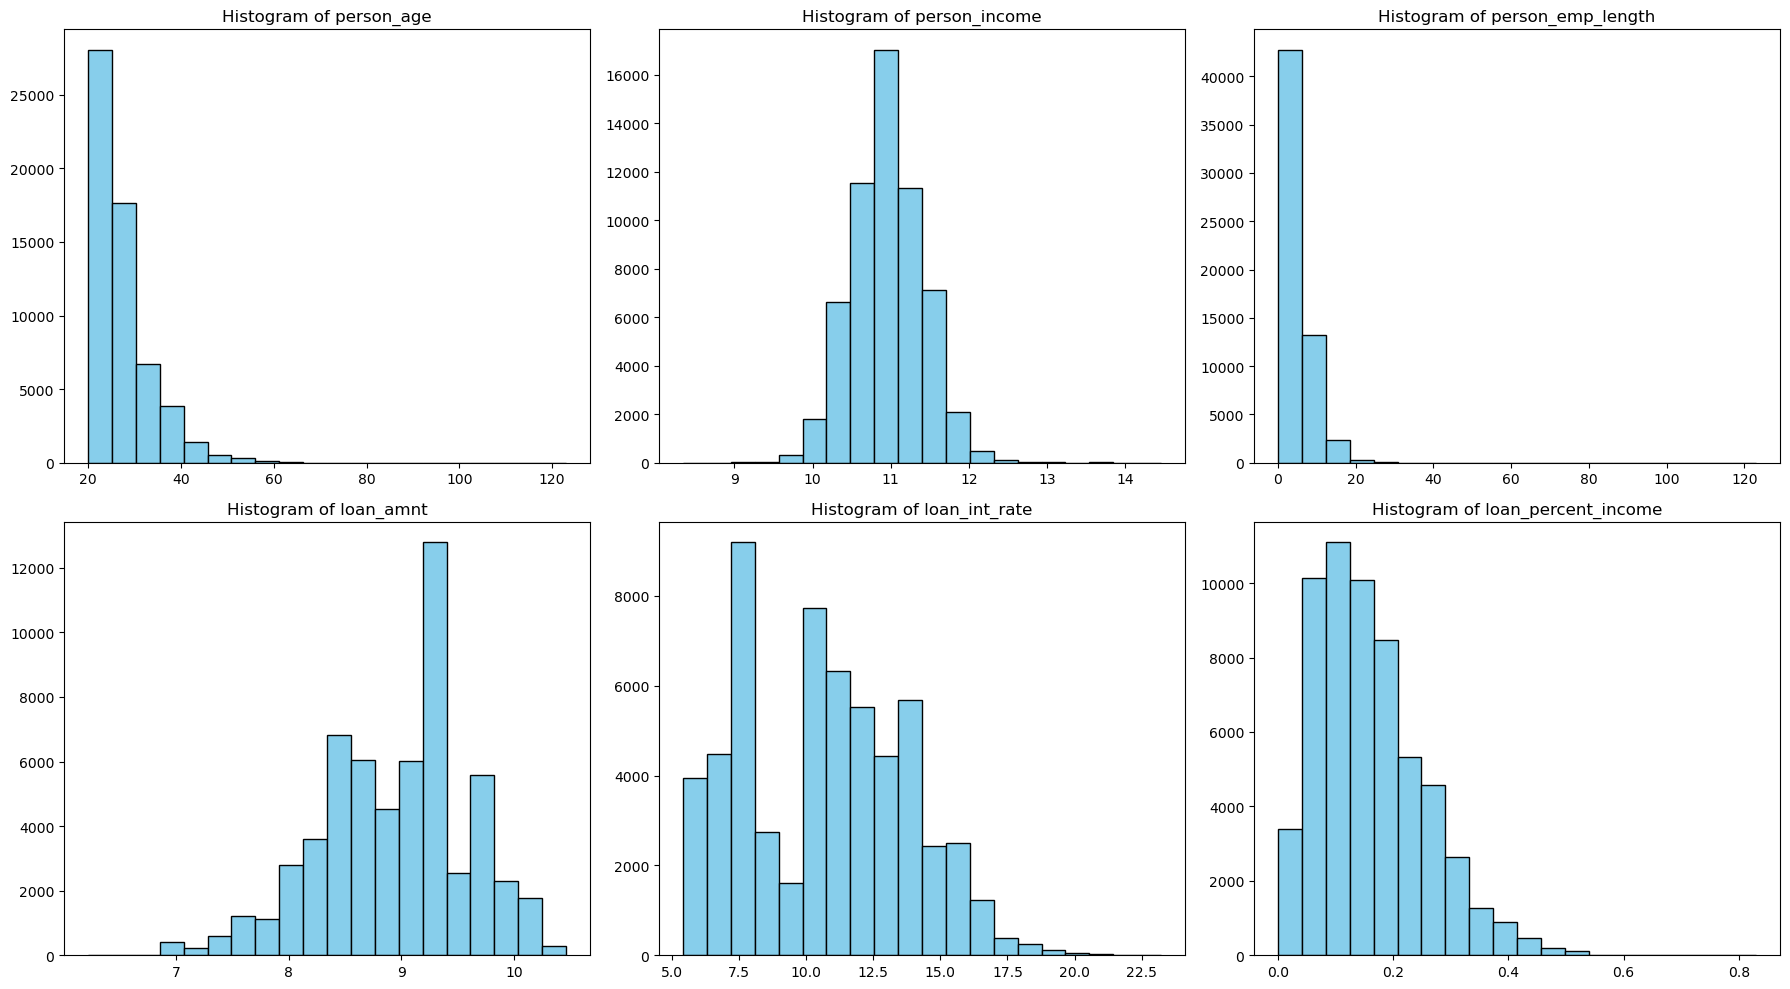

In [5]:
numeric_cols =["person_age", "person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()



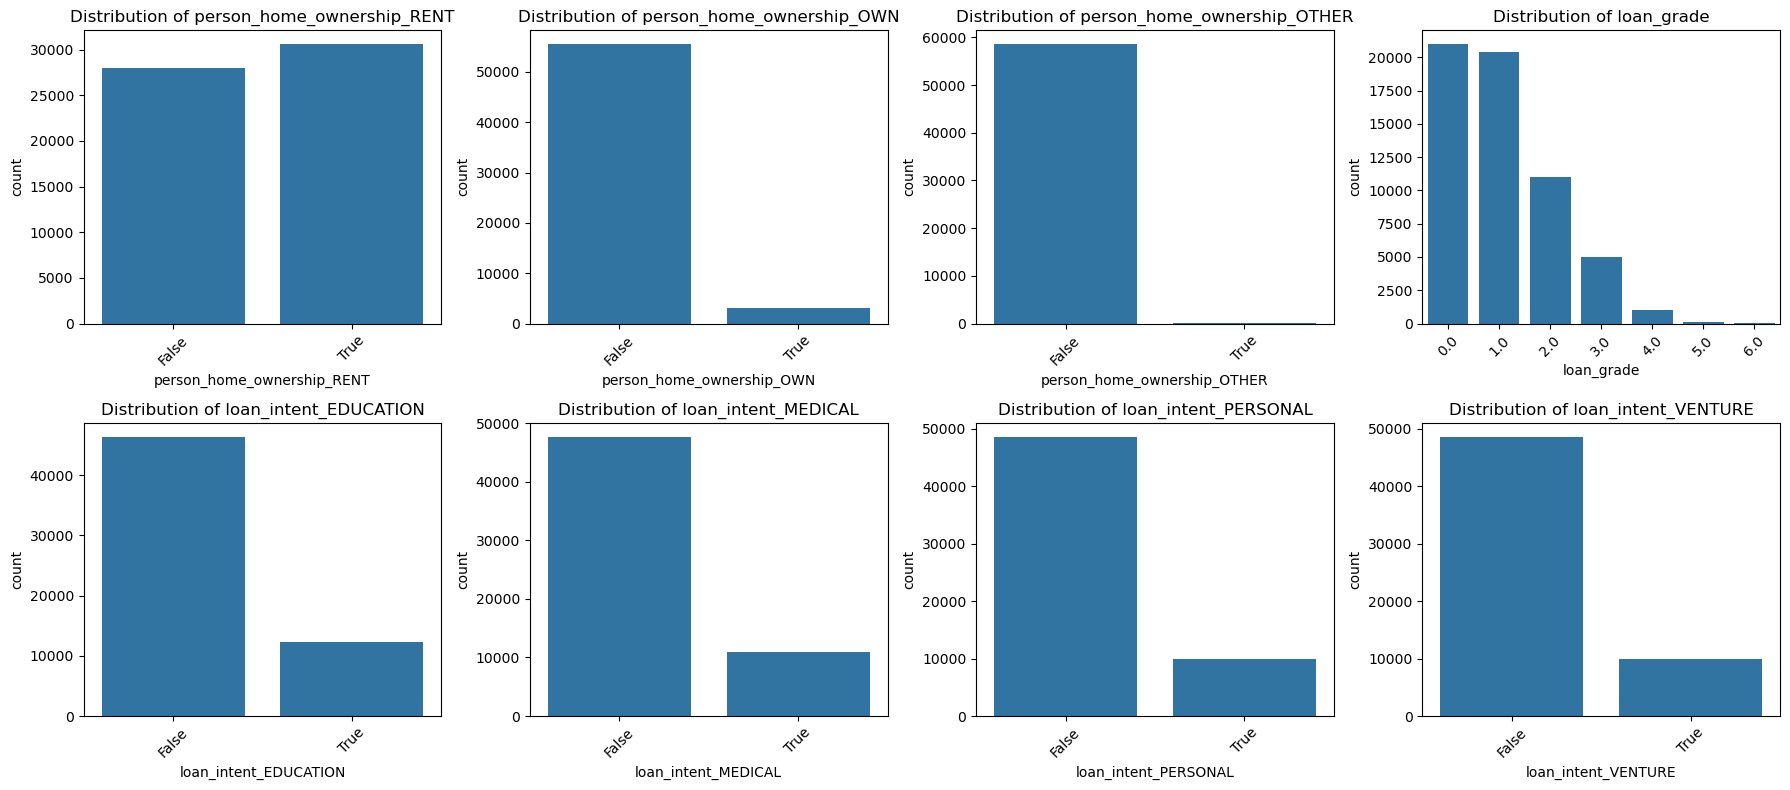

In [6]:
categorical_cols=[
    'person_home_ownership_RENT', 
    'person_home_ownership_OWN', 
    'person_home_ownership_OTHER',
    'loan_grade',
    'loan_intent_EDUCATION',
    'loan_intent_MEDICAL',
    'loan_intent_PERSONAL',
    'loan_intent_VENTURE']
fig,axes=plt.subplots(2, 4, figsize=(18, 8))
axes=axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df,ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

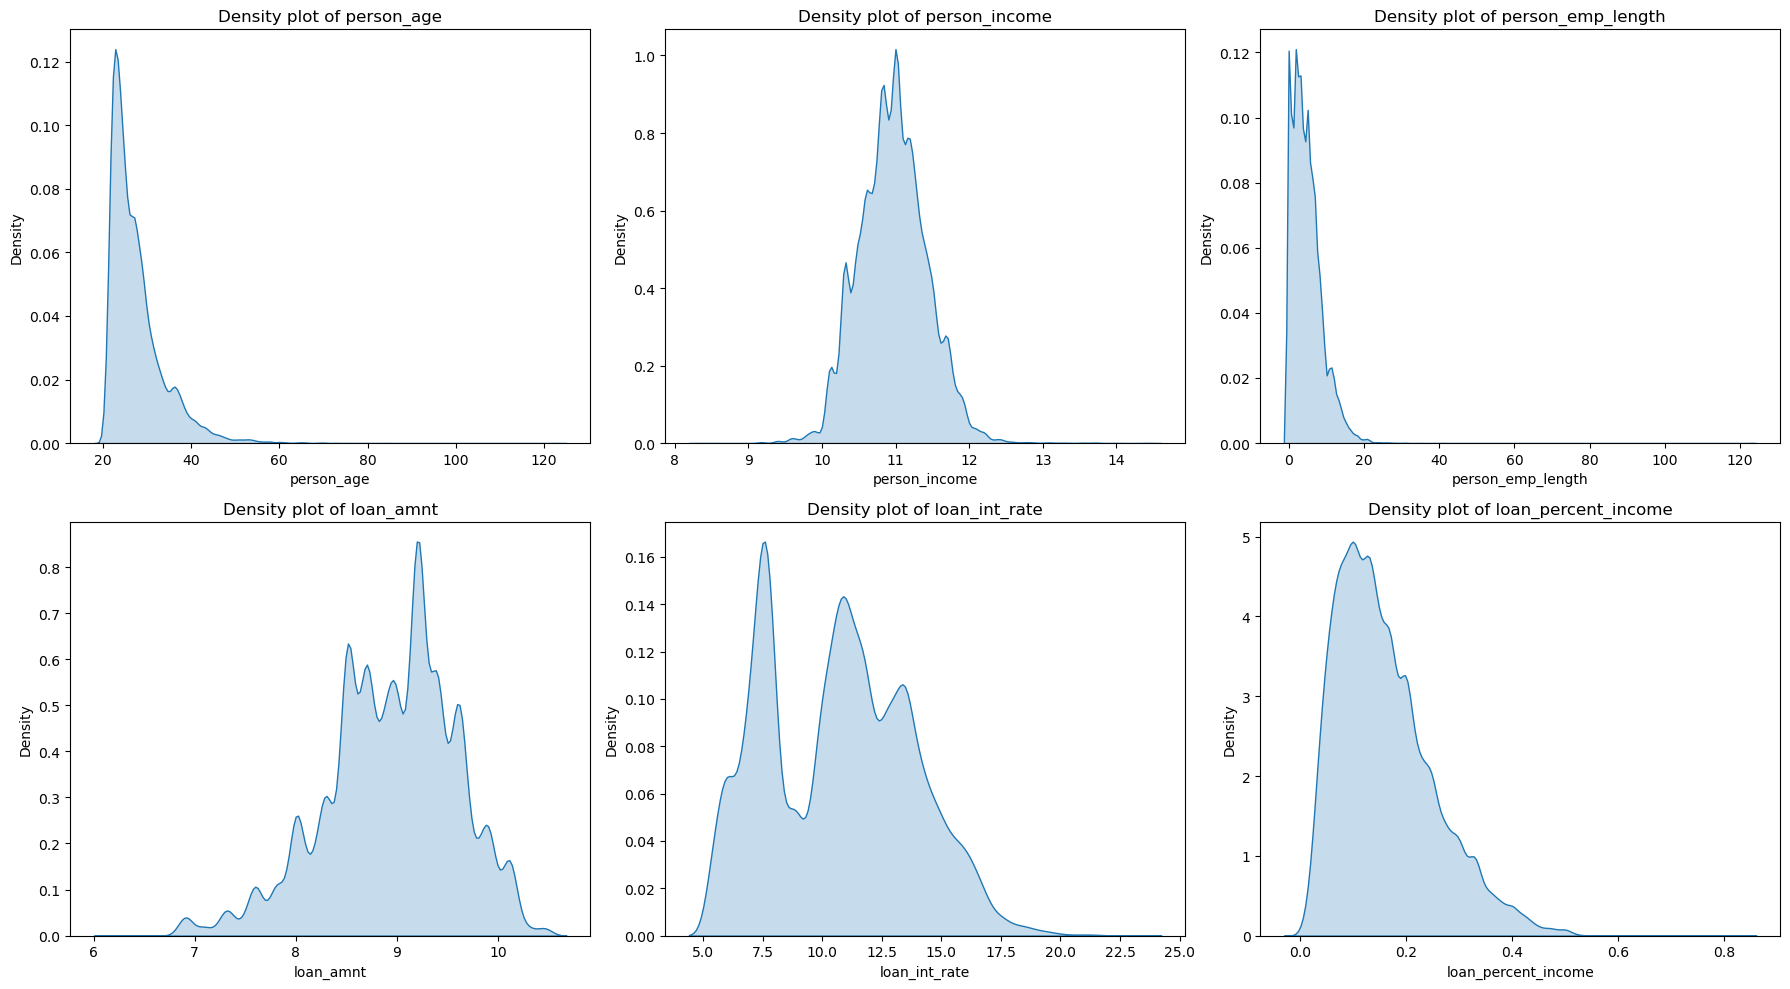

In [7]:
# Densité
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes=axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.kdeplot(df[col], fill=True, ax=axes[i])
    axes[i].set_title(f'Density plot of {col}')

plt.tight_layout()
plt.show()


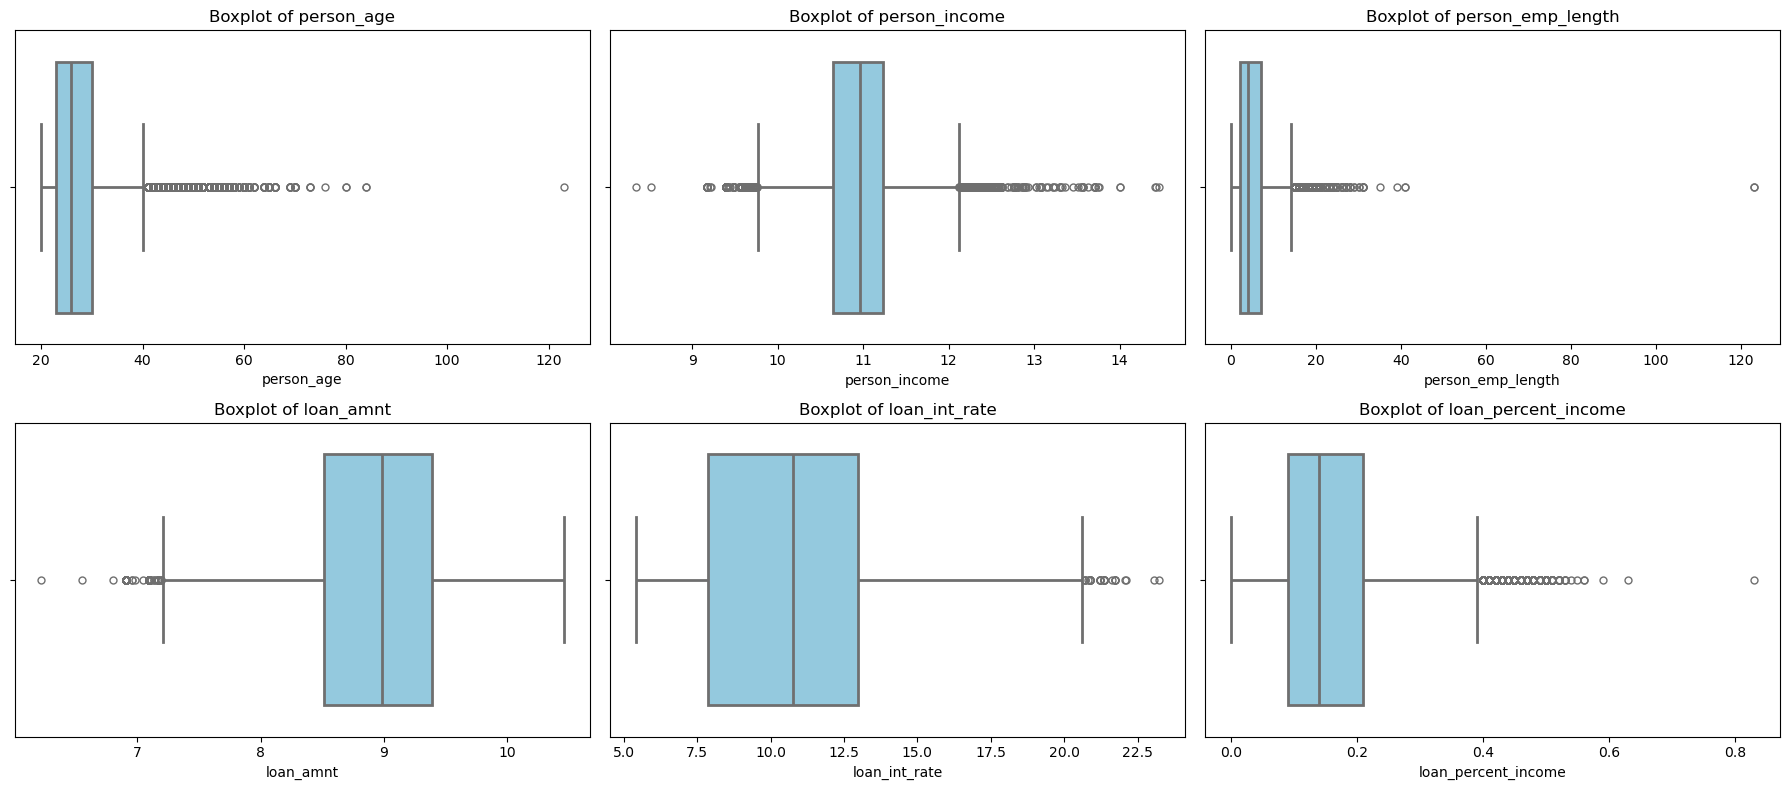

In [8]:
# Boxplost
fig,axes=plt.subplots(2, 3, figsize=(18, 8))
axes=axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df[col], 
        ax=axes[i], 
        color='skyblue',
        fliersize=5,
        linewidth=2
    )
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)

plt.tight_layout()
plt.show()

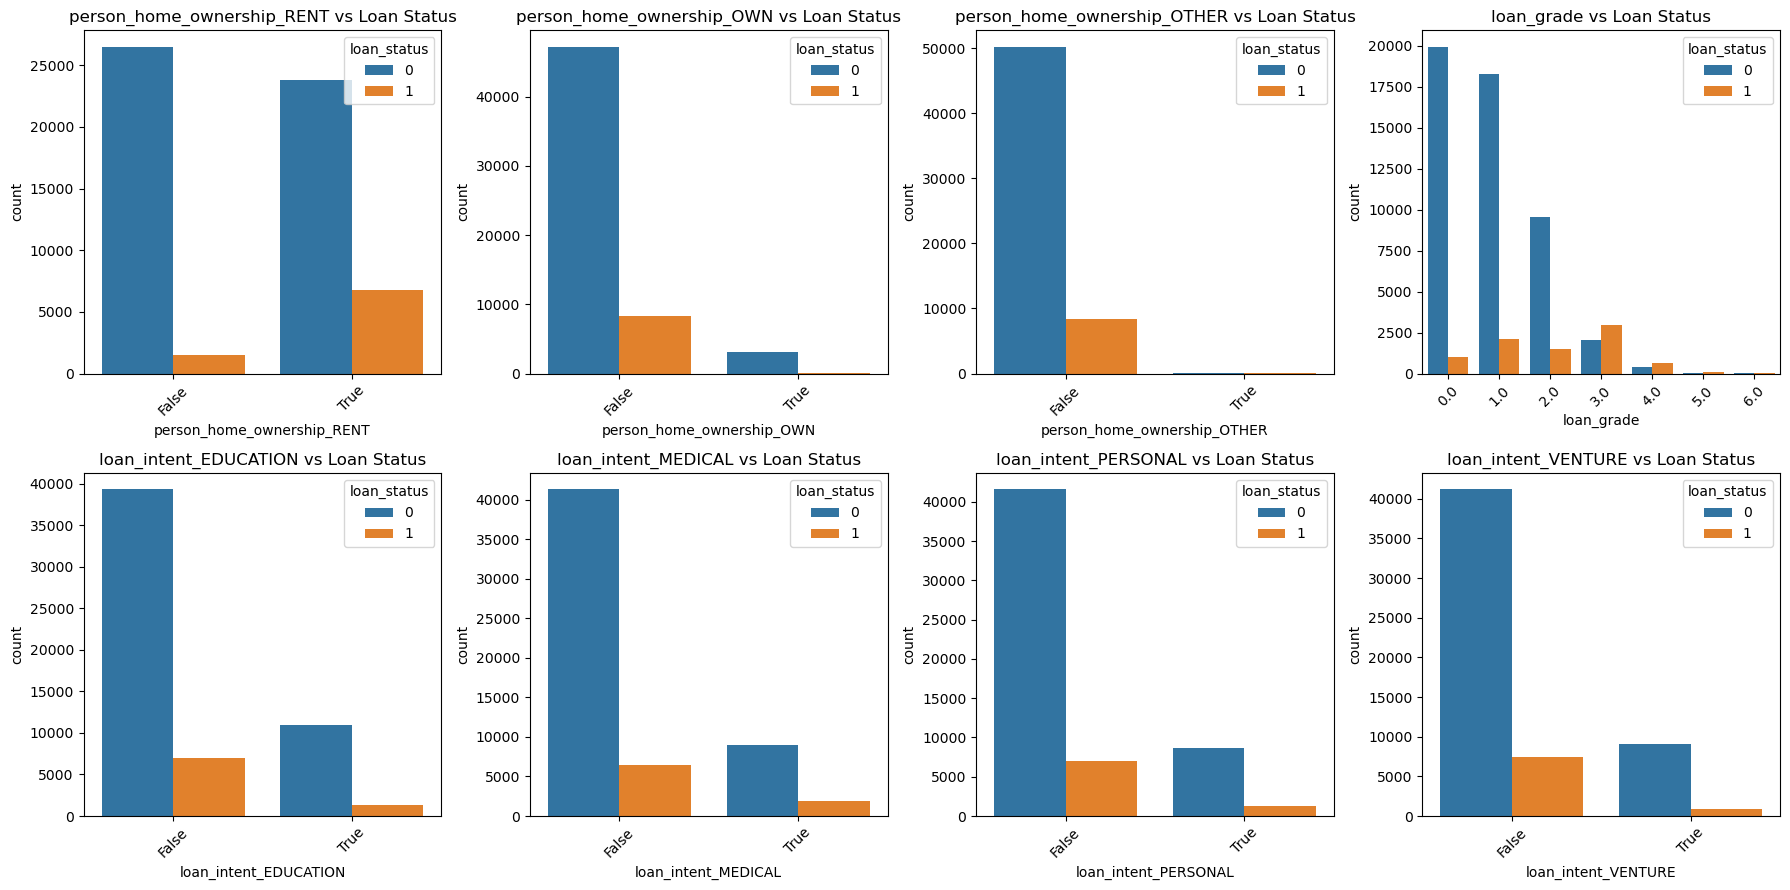

In [9]:
fig,axes=plt.subplots(2,4, figsize=(18, 9))
axes=axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col,hue='loan_status', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs Loan Status')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Formulation & Recap

Quelques formulations:
* Owners have a lower default risk.
* Tenants appear to be at higher risk.
* Loan grade is strongly correlated with default.

## Correlation != Causation

Les locataires font plus défaut.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ROC AUC Logistic

In [11]:
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_log.fit(X_train, y_train)
y_pred = pipe_log.predict_proba(X_val)[:,1]

print("ROC AUC Logistic:", roc_auc_score(y_val, y_pred))


ROC AUC Logistic: 0.9016187130659647


# Random Forest

In [12]:

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_val)[:,1]

print("ROC AUC RF:", roc_auc_score(y_val, y_pred_rf))


ROC AUC RF: 0.9345763885292345


# XGBoost

In [13]:

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict_proba(X_val)[:,1]

print("ROC AUC XGB:", roc_auc_score(y_val, y_pred_xgb))


ROC AUC XGB: 0.9551436941208546


# LightGBM

In [14]:
lgb = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

lgb.fit(X_train, y_train)
y_pred_lgb = lgb.predict_proba(X_val)[:,1]

print("ROC AUC LGBM:", roc_auc_score(y_val, y_pred_lgb))


[LightGBM] [Info] Number of positive: 6680, number of negative: 40236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000537 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1099
[LightGBM] [Info] Number of data points in the train set: 46916, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142382 -> initscore=-1.795644
[LightGBM] [Info] Start training from score -1.795644
ROC AUC LGBM: 0.9572123275072284


### ROC AUC Logistic: 0.8989578075181619
### ROC AUC RF: 0.9348043705399554
### ROC AUC XGB: 0.9520396385394577
### ROC AUC LGBM: 0.9547254368943144

Donc prenons le LGBM

In [15]:
df_test = pd.read_csv("test.csv")
df_test = preprocess_data(df_test)

y_test_pred = lgb.predict_proba(df_test)[:,1]

submission = pd.DataFrame({
    "id": df_test["id"],
    "loan_status": y_test_pred
})
submission.to_csv("submission.csv", index=False)
print("Fichier submission.csv créé")


Fichier submission.csv créé


In [16]:
print(len(y_test_pred))

39098
